# Tech Challenge 9IADT - Fase 2
> Thiago de Melo Lima - RM370763 - Whatsapp: 11949389623

## 🧠 Dados e Modelos

#### O sistema ***dIAbetes*** será capaz de ajudar médicos(as) e equipes clínicas na análise inicial de exames e no processamento de dados médicos com o objetivo de prever, com base em medições diagnósticas, se um paciente possui diabetes ou não.

## 📊 Dataset sobre Diabetes:

Esta base de dados contém **768 registros** com informações sobre características pessoais e fatores que podem influenciar o diagnóstico de diabetes em um paciente.

> [clique aqui para mais informações sobre o dataset](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data)
---



# Importação das biblietecas e referências do projeto

In [49]:
#importação das biblietecas e referencias do projeto
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from ollama import chat




# Modelo Original (Sem Otimização)

In [50]:
df_dIAbetes = pd.read_csv("../dataset/raw/diabetes.csv", low_memory=False) #carregando a base de dados

In [51]:
# features escolhidas para o diagnóstico
vars_diagnostico=['Glucose','BMI','Age','Pregnancies','DiabetesPedigreeFunction']

X = df_dIAbetes[vars_diagnostico] #variaveis independentes
y = df_dIAbetes['Outcome'] #target

Em seguida, dividimos os dados em treino e teste, utilizando 80% para treino e 20% para teste:

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2, #20% para teste e 80% de treino
                                                     stratify=y, #distribuir de forma igual entre treino e teste
                                                     random_state=7) #semente aleatoria
print(X_train.shape)
print(X_test.shape)

(614, 5)
(154, 5)


# Pipeline do Random Forest
> Com SMOTE para balanceamento das classes

In [53]:
pipeline_random_forest = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=7)),
    ('model', RandomForestClassifier(
        criterion='entropy',
        n_estimators=80,
        max_depth=2,
        class_weight='balanced',
        random_state=7
    ))
])

pipeline_random_forest.fit(X_train, y_train)

y_pred_random_forest = pipeline_random_forest.predict(X_test)

In [54]:
y_predito_random_forest = pipeline_random_forest.predict(X_test) 

In [100]:
# Metricas de precisão, revocação, f1-score e acurácia.
acuracia_base = accuracy_score(y_test, y_pred_random_forest)
precisao_base = precision_score(y_test, y_pred_random_forest)
recall_base = recall_score(y_test, y_pred_random_forest)
f1_base = f1_score(y_test, y_pred_random_forest)

print("Modelo Base - Random Forest - Sem Otimização de Hiperparâmetros")
print("n_estimators = 80")
print("max_depth = 2")
print(f"Acurácia: {acuracia_base:.4f}")
print(f"Precisão: {precisao_base:.4f}")
print(f"Recall: {recall_base:.4f}")
print(f"F1-Score: {f1_base:.4f}")

matriz_confusao = confusion_matrix(y_test, y_pred_random_forest)

tn, fp, fn, tp = matriz_confusao.ravel()

especificidade_base = tn / (tn + fp)

print(f"Especificidade: {especificidade_base:.4f}")

Modelo Base - Random Forest - Sem Otimização de Hiperparâmetros
n_estimators = 80
max_depth = 2
Acurácia: 0.8052
Precisão: 0.7000
Recall: 0.7778
F1-Score: 0.7368
Especificidade: 0.8200


## Resultado do modelo base (baseline) salvo para futuras comparações

In [56]:
resultado_modelo_base = {
    "acuracia": acuracia_base,
    "precisao": precisao_base,
    "recall": recall_base,
    "f1_score": f1_base,
    "especificidade": especificidade_base
}

resultado_modelo_base

{'acuracia': 0.8051948051948052,
 'precisao': 0.7,
 'recall': 0.7777777777777778,
 'f1_score': 0.7368421052631579,
 'especificidade': np.float64(0.82)}

# Resumo dos Resultados da Fase 1
> Desempenho do modelo selecionado para otimização

Na Fase 1 foi desenvolvido um modelo de Machine Learning para predição de diabetes, sendo o algoritmo **Random Forest** selecionado como modelo base por apresentar o melhor equilíbrio entre as métricas de avaliação. O modelo alcançou **81% de acurácia**, **70% de precisão**, **78% de recall** e **74% de F1-Score** para a classe positiva (pacientes diabéticos), além de **87% de precisão**, **82% de recall** e **85% de F1-Score** para a classe negativa.

Esses resultados demonstram uma boa capacidade de classificação de pacientes com maior probabilidade de diabetes, tornando o modelo adequado como ferramenta de apoio à decisão médica. Entretanto, ainda existem oportunidades de melhoria, principalmente na redução de falsos negativos e no aperfeiçoamento das métricas de classificação.

Dessa forma, nesta segunda fase, esse modelo será utilizado como ponto de partida para aplicação de **Algoritmos Genéticos**, com o objetivo de encontrar automaticamente uma combinação de hiperparâmetros que proporcione melhor desempenho e, posteriormente, integrá-lo a uma **Large Language Model (LLM)** para geração de explicações em linguagem natural.


# Otimização de Hiperparâmetros com Algoritmo Genético

O modelo base desenvolvido na Fase 1 utilizava os hiperparâmetros **n_estimators = 80** e **max_depth = 2**. Nesta segunda fase, será implementado um **Algoritmo Genético (AG)** com o objetivo de encontrar automaticamente a combinação de valores que proporcione o melhor desempenho para esses hiperparâmetros, mantendo os demais parâmetros do modelo inalterados.


## Função de Geração de Indivíduos

In [57]:
def gerar_individuo():
    """
    Gera um indivíduo aleatório para o Algoritmo Genético.

    Gene 1: quantidade de árvores (n_estimators)
    Gene 2: profundidade máxima (max_depth)
    """

    n_estimators = random.randint(
        20,
        200
    )

    max_depth = random.randint(
        1,
        20
    )

    return [
        n_estimators,
        max_depth
    ]

## Teste Unitário - gerar_individuo()

In [58]:
def testar_gerar_individuo():

    individuo = gerar_individuo()

    assert isinstance(
        individuo,
        list
    ), "O indivíduo deve ser uma lista."

    assert len(
        individuo
    ) == 2, "O indivíduo deve possuir exatamente 2 genes."

    assert 20 <= individuo[0] <= 200, (
        "n_estimators deve estar entre 20 e 200."
    )

    assert 1 <= individuo[1] <= 20, (
        "max_depth deve estar entre 1 e 20."
    )

    print(
        "✅ Teste unitário da função gerar_individuo() executado com sucesso."
    )


# Executando o teste
testar_gerar_individuo()

✅ Teste unitário da função gerar_individuo() executado com sucesso.


## Função para Calcular o Fitness

In [59]:
def calcular_fitness(individuo):
    """
    Calcula o fitness de um indivíduo utilizando
    Recall, F1-Score e Especificidade.
    """

    n_estimators, max_depth = individuo

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=7)),
        ('model', RandomForestClassifier(
            criterion='entropy',
            class_weight='balanced',
            random_state=7,
            n_estimators=n_estimators,
            max_depth=max_depth
        ))
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    especificidade = tn / (tn + fp)

    fitness = (
        (0.7 * recall) +
        (0.1 * precision) +
        (0.1 * especificidade)
    )

    return fitness

## Teste Unitário - calcular_fitness()

In [60]:
def testar_calcular_fitness():

    individuo = [
        80,  # n_estimators
        2    # max_depth
    ]

    fitness = calcular_fitness(
        individuo
    )

    assert isinstance(
        fitness,
        float
    ), "O fitness deve ser um número decimal."

    assert 0 <= fitness <= 1, (
        "O fitness deve estar entre 0 e 1."
    )

    print(
        "✅ Teste unitário da função calcular_fitness() executado com sucesso."
    )


# Executando o teste
testar_calcular_fitness()

✅ Teste unitário da função calcular_fitness() executado com sucesso.


## Função de Seleção dos Pais

In [61]:
def selecionar_pais(
    populacao_avaliada,
    tamanho_torneio=3
):
    """
    Seleciona o melhor indivíduo entre os candidatos
    utilizando seleção por torneio.
    """

    candidatos = random.sample(
        populacao_avaliada,
        tamanho_torneio
    )

    melhor_individuo = max(
        candidatos,
        key=lambda candidato: candidato[1]
    )

    return melhor_individuo[0]

## Teste Unitário - selecionar_pais()

In [62]:
def testar_selecionar_pais():

    populacao_avaliada = [
        ([80, 2], 0.72),
        ([100, 4], 0.75),
        ([120, 6], 0.78),
        ([150, 8], 0.74)
    ]

    pai = selecionar_pais(
        populacao_avaliada
    )

    assert isinstance(
        pai,
        list
    ), "O pai selecionado deve ser uma lista."

    assert len(
        pai
    ) == 2, (
        "O indivíduo deve possuir exatamente 2 genes."
    )

    individuos = [
        individuo
        for individuo, _ in populacao_avaliada
    ]

    assert pai in individuos, (
        "O indivíduo selecionado deve pertencer à população."
    )

    print(
        "✅ Teste unitário da função selecionar_pais() executado com sucesso."
    )


# Executando o teste
testar_selecionar_pais()

✅ Teste unitário da função selecionar_pais() executado com sucesso.


## Função de Cruzamento

In [63]:
def cruzar(
    pai1,
    pai2
):
    """
    Realiza o cruzamento entre dois pais,
    combinando um gene de cada indivíduo
    para gerar dois novos filhos.
    """

    filho1 = [
        pai1[0],  # n_estimators
        pai2[1]   # max_depth
    ]

    filho2 = [
        pai2[0],  # n_estimators
        pai1[1]   # max_depth
    ]

    return (
        filho1,
        filho2
    )

## Teste Unitário - cruzar()

In [64]:
def testar_cruzar():

    pai1 = [80, 2]
    pai2 = [120, 6]

    filho1, filho2 = cruzar(
        pai1,
        pai2
    )

    # =====================================================
    # Tipo
    # =====================================================

    assert isinstance(
        filho1,
        list
    ), "O filho 1 deve ser uma lista."

    assert isinstance(
        filho2,
        list
    ), "O filho 2 deve ser uma lista."

    # =====================================================
    # Quantidade de genes
    # =====================================================

    assert len(
        filho1
    ) == 2, (
        "O filho 1 deve possuir 2 genes."
    )

    assert len(
        filho2
    ) == 2, (
        "O filho 2 deve possuir 2 genes."
    )

    # =====================================================
    # Cruzamento
    # =====================================================

    assert filho1 == [80, 6], (
        "O filho 1 foi gerado incorretamente."
    )

    assert filho2 == [120, 2], (
        "O filho 2 foi gerado incorretamente."
    )

    print(
        "✅ Teste unitário da função cruzar() executado com sucesso."
    )


# Executando o teste
testar_cruzar()

✅ Teste unitário da função cruzar() executado com sucesso.


## Função de Calcular a taxa de mutação adaptativa

In [65]:
def calcular_taxa_mutacao(
    taxa_mutacao,
    geracoes_sem_melhora
):
    """
    Calcula a taxa de mutação adaptativa.
    """

    if geracoes_sem_melhora < 3:

        return taxa_mutacao

    return min(
        1.0,
        taxa_mutacao +
        ((geracoes_sem_melhora - 2) * 0.2)
    )

## Teste Unitário - calcular_taxa_mutacao()

In [66]:
def testar_calcular_taxa_mutacao():

    # =====================================================
    # Sem estagnação
    # =====================================================

    assert calcular_taxa_mutacao(0.2, 0) == 0.2

    assert calcular_taxa_mutacao(0.2, 1) == 0.2

    assert calcular_taxa_mutacao(0.2, 2) == 0.2

    # =====================================================
    # Mutação adaptativa
    # =====================================================

    assert calcular_taxa_mutacao(0.2, 3) == 0.4

    assert calcular_taxa_mutacao(0.2, 4) == 0.6

    assert calcular_taxa_mutacao(0.2, 5) == 0.8

    assert calcular_taxa_mutacao(0.2, 6) == 1.0

    # =====================================================
    # Limite máximo
    # =====================================================

    assert calcular_taxa_mutacao(0.2, 7) == 1.0

    assert calcular_taxa_mutacao(0.2, 20) == 1.0

    print(
        "✓ Teste unitário da função calcular_taxa_mutacao() executado com sucesso."
    )


    # Executando o teste
    testar_calcular_taxa_mutacao()

## Função de Mutação

In [67]:
def mutar(
    individuo,
    taxa_mutacao=0.2,
    geracoes_sem_melhora=0
):
    """
    Realiza a mutação de um indivíduo.

    Caso o algoritmo permaneça estagnado por
    três ou mais gerações consecutivas,
    a taxa de mutação é aumentada
    progressivamente.
    """

    novo_individuo = individuo.copy()

    # ==========================================
    # Mutação adaptativa progressiva
    # ==========================================

    taxa_mutacao = calcular_taxa_mutacao(
        taxa_mutacao,
        geracoes_sem_melhora
    )
    
    
    # ==========================================
    # Mutação
    # ==========================================

    if random.random() < taxa_mutacao:

        indice_gene = random.randint(0, 1)

        if indice_gene == 0:

            novo_valor = individuo[0]

            while novo_valor == individuo[0]:

                novo_valor = random.randint(
                    20,
                    200
                )

            novo_individuo[0] = novo_valor

        else:

            novo_valor = individuo[1]

            while novo_valor == individuo[1]:

                novo_valor = random.randint(
                    1,
                    20
                )

            novo_individuo[1] = novo_valor

    return novo_individuo

## Teste Unitário - mutar()

In [68]:
def testar_mutar():

    individuo = [80, 2]

    # =====================================================
    # Sem mutação
    # =====================================================

    individuo_sem_mutacao = mutar(
        individuo,
        taxa_mutacao=0,
        geracoes_sem_melhora=0
    )

    assert individuo_sem_mutacao == individuo, (
        "O indivíduo não deveria sofrer mutação."
    )

    # =====================================================
    # Mutação normal (100%)
    # =====================================================

    individuo_mutado = mutar(
        individuo,
        taxa_mutacao=1,
        geracoes_sem_melhora=0
    )

    assert isinstance(
        individuo_mutado,
        list
    ), "O indivíduo mutado deve ser uma lista."

    assert len(
        individuo_mutado
    ) == 2, (
        "O indivíduo mutado deve possuir 2 genes."
    )

    assert 20 <= individuo_mutado[0] <= 200, (
        "n_estimators inválido após mutação."
    )

    assert 1 <= individuo_mutado[1] <= 20, (
        "max_depth inválido após mutação."
    )

    assert individuo_mutado != individuo, (
        "A mutação deveria alterar pelo menos um gene."
    )

    # =====================================================
    # Mutação adaptativa (estagnação)
    # =====================================================

    individuo_adaptativo = mutar(
        individuo,
        taxa_mutacao=0.2,
        geracoes_sem_melhora=5
    )

    assert isinstance(
        individuo_adaptativo,
        list
    ), "O indivíduo mutado deve ser uma lista."

    assert len(
        individuo_adaptativo
    ) == 2, (
        "O indivíduo mutado deve possuir 2 genes."
    )

    assert 20 <= individuo_adaptativo[0] <= 200, (
        "n_estimators inválido após mutação adaptativa."
    )

    assert 1 <= individuo_adaptativo[1] <= 20, (
        "max_depth inválido após mutação adaptativa."
    )

    print(
        "✅ Teste unitário da função mutar() executado com sucesso."
    )


# Executando o teste
testar_mutar()

✅ Teste unitário da função mutar() executado com sucesso.


## Função de Execução do Algoritmo Genético

In [69]:
def executar_algoritmo_genetico(
    tamanho_populacao=20,
    numero_geracoes=10,
    taxa_mutacao=0.2,
    exibir_progresso=True
):
    """
    Executa o Algoritmo Genético para otimização dos
    hiperparâmetros do Random Forest.
    """

    # =====================================================
    # População inicial
    # =====================================================

    populacao = [
        gerar_individuo()
        for _ in range(tamanho_populacao)
    ]

    melhor_individuo = None
    melhor_fitness = 0

    geracoes_sem_melhora = 0

    historico_melhor = []
    historico_medio = []
    historico_pior = []

    # =====================================================
    # Evolução
    # =====================================================

    for geracao in range(numero_geracoes):

        # =================================================
        # Avaliação da população
        # =================================================

        populacao_avaliada = [
            (
                individuo,
                calcular_fitness(individuo)
            )
            for individuo in populacao
        ]

        populacao_avaliada.sort(
            key=lambda individuo: individuo[1],
            reverse=True
        )

        melhor_da_geracao = populacao_avaliada[0][0]
        fitness_da_geracao = populacao_avaliada[0][1]

        # =================================================
        # Estatísticas da geração
        # =================================================

        fitness_populacao = [
            fitness
            for _, fitness in populacao_avaliada
        ]

        menor_fitness = min(
            fitness_populacao
        )

        fitness_medio = (
            sum(fitness_populacao)
            / len(fitness_populacao)
        )

        maior_fitness = max(
            fitness_populacao
        )

        historico_melhor.append(
            maior_fitness
        )

        historico_medio.append(
            fitness_medio
        )

        historico_pior.append(
            menor_fitness
        )

        # =================================================
        # Log da geração
        # =================================================

        if exibir_progresso:

            taxa_atual = calcular_taxa_mutacao(
                taxa_mutacao,
                geracoes_sem_melhora
            )

            print(
                f"Geração {geracao + 1:02d} | "
                f"Menor fitness: {menor_fitness:.4f} | "
                f"Fitness médio: {fitness_medio:.4f} | "
                f"Melhor fitness: {maior_fitness:.4f} | "
                f"Mutação: {taxa_atual:.1f} | "
                f"Indivíduo: {melhor_da_geracao}"
            )

            if geracoes_sem_melhora >= 3:

                print(
                    f"⚠ Nenhuma melhoria nas últimas "
                    f"{geracoes_sem_melhora} gerações. "
                    f"Taxa de mutação ajustada para "
                    f"{taxa_atual:.1f}."
                )

        # =================================================
        # Atualiza melhor solução encontrada
        # =================================================

        if fitness_da_geracao > melhor_fitness:

            melhor_fitness = fitness_da_geracao

            melhor_individuo = melhor_da_geracao.copy()

            if (
                geracoes_sem_melhora >= 3
                and exibir_progresso
            ):

                print(
                    "✓ Melhoria encontrada. "
                    "Retornando para a taxa de mutação padrão."
                )

            geracoes_sem_melhora = 0

        else:

            geracoes_sem_melhora += 1

        # =================================================
        # Elitismo
        # =================================================

        nova_populacao = [
            melhor_da_geracao.copy()
        ]

        while len(nova_populacao) < tamanho_populacao:

            pai1 = selecionar_pais(
                populacao_avaliada
            )

            pai2 = selecionar_pais(
                populacao_avaliada
            )

            tentativas = 0

            while (
                pai1 == pai2
                and tentativas < 5
            ):

                pai2 = selecionar_pais(
                    populacao_avaliada
                )

                tentativas += 1

            filho1, filho2 = cruzar(
                pai1,
                pai2
            )

            filho1 = mutar(
                filho1,
                taxa_mutacao=taxa_mutacao,
                geracoes_sem_melhora=geracoes_sem_melhora
            )

            filho2 = mutar(
                filho2,
                taxa_mutacao=taxa_mutacao,
                geracoes_sem_melhora=geracoes_sem_melhora
            )

            nova_populacao.append(
                filho1
            )

            if len(nova_populacao) < tamanho_populacao:

                nova_populacao.append(
                    filho2
                )

        populacao = nova_populacao

    return (
        melhor_individuo,
        melhor_fitness,
        historico_melhor,
        historico_medio,
        historico_pior
    )

## Teste Unitário - executar_algoritmo_genetico()

In [70]:
def testar_executar_algoritmo_genetico():

    (
        melhor_individuo,
        melhor_fitness,
        historico_melhor,
        historico_medio,
        historico_pior
    ) = executar_algoritmo_genetico(
        tamanho_populacao=5,
        numero_geracoes=3,
        taxa_mutacao=0.2,
        exibir_progresso=False
    )

    # =====================================================
    # Melhor indivíduo
    # =====================================================

    assert isinstance(
        melhor_individuo,
        list
    ), "O melhor indivíduo deve ser uma lista."

    assert len(
        melhor_individuo
    ) == 2, (
        "O melhor indivíduo deve possuir exatamente 2 genes."
    )

    # =====================================================
    # Melhor fitness
    # =====================================================

    assert isinstance(
        melhor_fitness,
        float
    ), "O fitness deve ser um número decimal."

    assert 0 <= melhor_fitness <= 1, (
        "O fitness deve estar entre 0 e 1."
    )

    # =====================================================
    # Históricos
    # =====================================================

    assert isinstance(
        historico_melhor,
        list
    ), "O histórico do melhor fitness deve ser uma lista."

    assert isinstance(
        historico_medio,
        list
    ), "O histórico do fitness médio deve ser uma lista."

    assert isinstance(
        historico_pior,
        list
    ), "O histórico do pior fitness deve ser uma lista."

    assert len(
        historico_melhor
    ) == 3, (
        "O histórico do melhor fitness deve possuir um valor por geração."
    )

    assert len(
        historico_medio
    ) == 3, (
        "O histórico do fitness médio deve possuir um valor por geração."
    )

    assert len(
        historico_pior
    ) == 3, (
        "O histórico do pior fitness deve possuir um valor por geração."
    )

    # =====================================================
    # Validação dos valores
    # =====================================================

    for melhor, medio, pior in zip(
        historico_melhor,
        historico_medio,
        historico_pior
    ):

        assert 0 <= pior <= 1, (
            "O pior fitness deve estar entre 0 e 1."
        )

        assert 0 <= medio <= 1, (
            "O fitness médio deve estar entre 0 e 1."
        )

        assert 0 <= melhor <= 1, (
            "O melhor fitness deve estar entre 0 e 1."
        )

        assert pior <= medio <= melhor, (
            "Os históricos estão inconsistentes."
        )

    # =====================================================
    # Melhor fitness encontrado
    # =====================================================

    assert melhor_fitness == max(
        historico_melhor
    ), (
        "O melhor fitness retornado deve ser igual ao maior fitness do histórico."
    )

    print(
        "✅ Teste unitário da função executar_algoritmo_genetico() executado com sucesso."
    )


# Executando o teste
testar_executar_algoritmo_genetico()

✅ Teste unitário da função executar_algoritmo_genetico() executado com sucesso.


## Função para Executar os Experimentos do Algoritmo Genético

In [71]:
def executar_experimento(
    nome_experimento,
    tamanho_populacao,
    numero_geracoes,
    taxa_mutacao=0.1,
    exibir_grafico=True
):
    """
    Executa um experimento utilizando o Algoritmo Genético
    e avalia o modelo otimizado.
    """

    (
        melhor_individuo,
        melhor_fitness,
        historico_melhor,
        historico_medio,
        historico_pior
    ) = executar_algoritmo_genetico(
        tamanho_populacao=tamanho_populacao,
        numero_geracoes=numero_geracoes,
        taxa_mutacao=taxa_mutacao,
        exibir_progresso=True
    )

    # =====================================================
    # Gráfico da evolução do fitness
    # =====================================================

    if exibir_grafico:

        plt.figure(figsize=(10, 5))

        plt.plot(
            historico_melhor,
            marker="o",
            label="Melhor Fitness"
        )

        plt.plot(
            historico_medio,
            marker="s",
            label="Fitness Médio"
        )

        plt.plot(
            historico_pior,
            marker="^",
            label="Pior Fitness"
        )

        plt.title(
            f"Evolução do Fitness - {nome_experimento}"
        )

        plt.xlabel("Geração")

        plt.ylabel("Fitness")

        plt.grid(True)

        plt.legend()

        plt.show()

        print("\nResumo do experimento\n")

        print(
            f"Melhor indivíduo: {melhor_individuo}"
        )

        print(
            f"Melhor Fitness: {melhor_fitness:.4f}"
        )

    # =====================================================
    # Treina o modelo otimizado
    # =====================================================

    melhor_n_estimators = melhor_individuo[0]
    melhor_max_depth = melhor_individuo[1]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=7)),
        ("model", RandomForestClassifier(
            criterion="entropy",
            class_weight="balanced",
            random_state=7,
            n_estimators=melhor_n_estimators,
            max_depth=melhor_max_depth
        ))
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    # =====================================================
    # Métricas finais
    # =====================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    # =====================================================
    # Resultado do experimento
    # =====================================================

    return {
        "Experimento": nome_experimento,
        "População": tamanho_populacao,
        "Gerações": numero_geracoes,
        "Mutação": taxa_mutacao,
        "n_estimators": melhor_n_estimators,
        "max_depth": melhor_max_depth,

        "Menor Fitness": round(
            min(historico_pior),
            4
        ),

        "Fitness Médio": round(
            sum(historico_medio) /
            len(historico_medio),
            4
        ),

        "Maior Fitness": round(
            max(historico_melhor),
            4
        ),

        "Accuracy": round(
            accuracy,
            4
        ),

        "Precision": round(
            precision,
            4
        ),

        "Recall": round(
            recall,
            4
        ),

        "F1": round(
            f1,
            4
        )
    }

## Teste Unitário - executar_experimento()

In [72]:
def testar_executar_experimento():

    resultado = executar_experimento(
        nome_experimento="Teste",
        tamanho_populacao=5,
        numero_geracoes=3,
        taxa_mutacao=0.1,
        exibir_grafico=False
    )

    # =====================================================
    # Tipo de retorno
    # =====================================================

    assert isinstance(
        resultado,
        dict
    ), "O resultado deve ser um dicionário."

    # =====================================================
    # Chaves esperadas
    # =====================================================

    chaves_esperadas = [
        "Experimento",
        "População",
        "Gerações",
        "Mutação",
        "n_estimators",
        "max_depth",
        "Menor Fitness",
        "Fitness Médio",
        "Maior Fitness",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]

    for chave in chaves_esperadas:

        assert chave in resultado, (
            f"A chave '{chave}' não foi encontrada no resultado."
        )

    # =====================================================
    # Intervalo dos hiperparâmetros
    # =====================================================

    assert 20 <= resultado["n_estimators"] <= 200, (
        "n_estimators inválido."
    )

    assert 1 <= resultado["max_depth"] <= 20, (
        "max_depth inválido."
    )

    # =====================================================
    # Fitness
    # =====================================================

    assert 0 <= resultado["Menor Fitness"] <= 1, (
        "Menor Fitness inválido."
    )

    assert 0 <= resultado["Fitness Médio"] <= 1, (
        "Fitness Médio inválido."
    )

    assert 0 <= resultado["Maior Fitness"] <= 1, (
        "Maior Fitness inválido."
    )

    assert (
        resultado["Menor Fitness"]
        <= resultado["Fitness Médio"]
        <= resultado["Maior Fitness"]
    ), (
        "Os valores de fitness estão inconsistentes."
    )

    # =====================================================
    # Métricas
    # =====================================================

    assert 0 <= resultado["Accuracy"] <= 1, (
        "Accuracy inválida."
    )

    assert 0 <= resultado["Precision"] <= 1, (
        "Precision inválida."
    )

    assert 0 <= resultado["Recall"] <= 1, (
        "Recall inválido."
    )

    assert 0 <= resultado["F1"] <= 1, (
        "F1-Score inválido."
    )

    print(
        "✅ Teste unitário da função executar_experimento() executado com sucesso."
    )


# Executando o teste
testar_executar_experimento()

Geração 01 | Menor fitness: 0.6289 | Fitness médio: 0.6528 | Melhor fitness: 0.6717 | Mutação: 0.1 | Indivíduo: [171, 9]
Geração 02 | Menor fitness: 0.6334 | Fitness médio: 0.6691 | Melhor fitness: 0.6943 | Mutação: 0.1 | Indivíduo: [120, 3]
Geração 03 | Menor fitness: 0.6695 | Fitness médio: 0.6821 | Melhor fitness: 0.6943 | Mutação: 0.1 | Indivíduo: [120, 3]
✅ Teste unitário da função executar_experimento() executado com sucesso.


# O Algoritmo Genético Encontrou Hiperparâmetros Melhores?

Nesta seção são apresentados os resultados obtidos em cada experimento realizado com diferentes configurações do Algoritmo Genético, permitindo comparar o desempenho dos hiperparâmetros encontrados em relação ao modelo base.

## Experimento 1

Geração 01 | Menor fitness: 0.6334 | Fitness médio: 0.6625 | Melhor fitness: 0.6852 | Mutação: 0.1 | Indivíduo: [50, 9]
Geração 02 | Menor fitness: 0.6470 | Fitness médio: 0.6720 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [31, 13]
Geração 03 | Menor fitness: 0.6447 | Fitness médio: 0.6749 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [31, 13]
Geração 04 | Menor fitness: 0.6651 | Fitness médio: 0.6805 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [31, 13]
Geração 05 | Menor fitness: 0.6695 | Fitness médio: 0.6850 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [31, 13]
Geração 06 | Menor fitness: 0.6582 | Fitness médio: 0.6852 | Melhor fitness: 0.6986 | Mutação: 0.3 | Indivíduo: [31, 13]
⚠ Nenhuma melhoria nas últimas 3 gerações. Taxa de mutação ajustada para 0.3.
Geração 07 | Menor fitness: 0.6560 | Fitness médio: 0.6901 | Melhor fitness: 0.6986 | Mutação: 0.5 | Indivíduo: [31, 13]
⚠ Nenhuma melhoria nas últimas 4 gerações. Taxa de mutação ajustada para 0.5

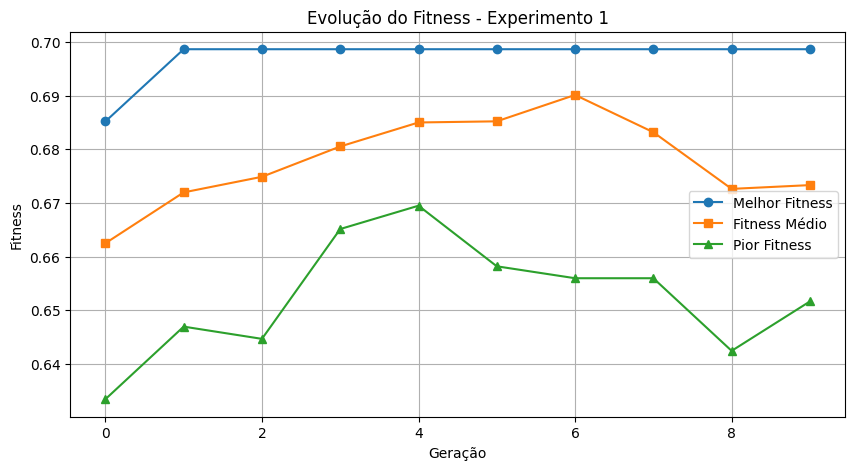


Resumo do experimento

Melhor indivíduo: [31, 13]
Melhor Fitness: 0.6986


In [73]:
resultado_exp_1 = executar_experimento(
    nome_experimento="Experimento 1",
    tamanho_populacao=10,
    numero_geracoes=10
)



## Experimento 2

Geração 01 | Menor fitness: 0.6334 | Fitness médio: 0.6641 | Melhor fitness: 0.6956 | Mutação: 0.1 | Indivíduo: [35, 1]
Geração 02 | Menor fitness: 0.6358 | Fitness médio: 0.6743 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [161, 1]
Geração 03 | Menor fitness: 0.6582 | Fitness médio: 0.6879 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [161, 1]
Geração 04 | Menor fitness: 0.6493 | Fitness médio: 0.6939 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [161, 1]
Geração 05 | Menor fitness: 0.6766 | Fitness médio: 0.7055 | Melhor fitness: 0.7150 | Mutação: 0.1 | Indivíduo: [161, 1]
Geração 06 | Menor fitness: 0.6667 | Fitness médio: 0.7041 | Melhor fitness: 0.7150 | Mutação: 0.3 | Indivíduo: [161, 1]
⚠ Nenhuma melhoria nas últimas 3 gerações. Taxa de mutação ajustada para 0.3.
Geração 07 | Menor fitness: 0.6470 | Fitness médio: 0.7039 | Melhor fitness: 0.7150 | Mutação: 0.5 | Indivíduo: [161, 1]
⚠ Nenhuma melhoria nas últimas 4 gerações. Taxa de mutação ajustada para 0.5

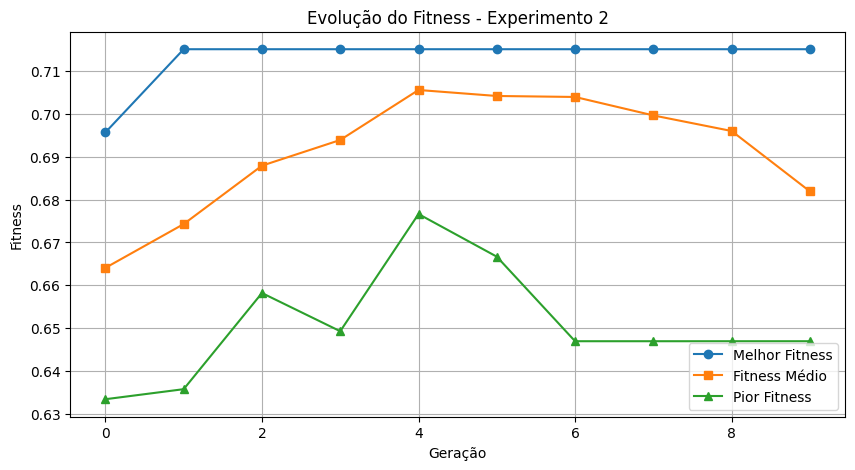


Resumo do experimento

Melhor indivíduo: [161, 1]
Melhor Fitness: 0.7150


In [74]:
resultado_exp_2 = executar_experimento(
    nome_experimento="Experimento 2",
    tamanho_populacao=20,
    numero_geracoes=10
)



## Experimento 3

Geração 01 | Menor fitness: 0.6470 | Fitness médio: 0.6680 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [154, 4]
Geração 02 | Menor fitness: 0.6695 | Fitness médio: 0.6800 | Melhor fitness: 0.6964 | Mutação: 0.1 | Indivíduo: [154, 4]
Geração 03 | Menor fitness: 0.6717 | Fitness médio: 0.6853 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [154, 2]
Geração 04 | Menor fitness: 0.6786 | Fitness médio: 0.6927 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [154, 2]
Geração 05 | Menor fitness: 0.6628 | Fitness médio: 0.6909 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [154, 2]
Geração 06 | Menor fitness: 0.6493 | Fitness médio: 0.6911 | Melhor fitness: 0.6986 | Mutação: 0.1 | Indivíduo: [154, 2]
Geração 07 | Menor fitness: 0.6493 | Fitness médio: 0.6874 | Melhor fitness: 0.6986 | Mutação: 0.3 | Indivíduo: [154, 2]
⚠ Nenhuma melhoria nas últimas 3 gerações. Taxa de mutação ajustada para 0.3.
Geração 08 | Menor fitness: 0.6176 | Fitness médio: 0.6821 | Melhor fitness

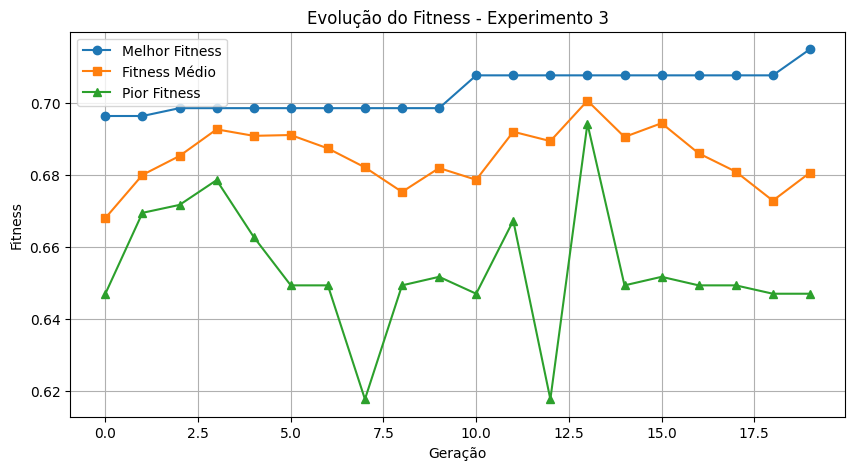


Resumo do experimento

Melhor indivíduo: [160, 1]
Melhor Fitness: 0.7150


In [75]:
resultado_exp_3 = executar_experimento(
    nome_experimento="Experimento 3",
    tamanho_populacao=20,
    numero_geracoes=20
)

## Comparação dos Experimentos

In [76]:
resultados_experimentos = pd.DataFrame([
    resultado_exp_1,
    resultado_exp_2,
    resultado_exp_3
])

resultados_experimentos

,Experimento,População,Gerações,Mutação,n_estimators,max_depth,Menor Fitness,Fitness Médio,Maior Fitness,Accuracy,Precision,Recall,F1
0,Experimento 1,10,10,0.1,31,13,0.6334,0.6779,0.6986,0.8117,0.7119,0.7778,0.7434
1,Experimento 2,20,10,0.1,161,1,0.6334,0.6911,0.7150,0.7922,0.6667,0.8148,0.7333
2,Experimento 3,20,20,0.1,160,1,0.6176,0.6851,0.7150,0.7922,0.6667,0.8148,0.7333


## Seleção do Melhor Experimento

In [77]:
melhor_experimento = resultados_experimentos.loc[
    resultados_experimentos["Maior Fitness"].idxmax()
]

melhor_experimento

Experimento      Experimento 2
População                   20
Gerações                    10
Mutação                    0.1
n_estimators               161
max_depth                    1
Menor Fitness           0.6334
Fitness Médio           0.6911
Maior Fitness            0.715
Accuracy                0.7922
Precision               0.6667
Recall                  0.8148
F1                      0.7333
Name: 1, dtype: object

# Melhor Configuração

In [78]:
melhor_n_estimators = melhor_experimento["n_estimators"]

melhor_max_depth = melhor_experimento["max_depth"]

print(f"Melhor n_estimators: {melhor_n_estimators}")
print(f"Melhor max_depth: {melhor_max_depth}")

Melhor n_estimators: 161
Melhor max_depth: 1


# Criação do Modelo Final Otimizado

Nesta etapa, o modelo final é treinado utilizando os hiperparâmetros encontrados no experimento que apresentou o melhor desempenho.

In [79]:
pipeline_random_forest_otimizado = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=7)),
    ('model', RandomForestClassifier(
        criterion='entropy',
        class_weight='balanced',
        random_state=7,
        n_estimators=int(melhor_n_estimators),
        max_depth=int(melhor_max_depth)
    ))
])

pipeline_random_forest_otimizado.fit(
    X_train,
    y_train
)

y_pred_random_forest_otimizado = (
    pipeline_random_forest_otimizado.predict(X_test)
)

## Obtendo e Armazenando as Métricas de Avaliação do Modelo Otimizado

In [80]:
acuracia_otimizada = accuracy_score(
    y_test,
    y_pred_random_forest_otimizado
)

precisao_otimizada = precision_score(
    y_test,
    y_pred_random_forest_otimizado
)

recall_otimizado = recall_score(
    y_test,
    y_pred_random_forest_otimizado
)

f1_otimizado = f1_score(
    y_test,
    y_pred_random_forest_otimizado
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_random_forest_otimizado
).ravel()

especificidade_otimizada = tn / (tn + fp)

In [101]:
print("Modelo Otimizado - Random Forest - Com Otimização de Hiperparâmetros Por Algoritmo Genético")
print(f"n_estimators = {melhor_n_estimators}")
print(f"max_depth = {melhor_max_depth}")
print(f"Acurácia: {acuracia_otimizada:.4f}")
print(f"Precisão: {precisao_otimizada:.4f}")
print(f"Recall: {recall_otimizado:.4f}")
print(f"F1-Score: {f1_otimizado:.4f}")
print(f"Especificidade: {especificidade_otimizada:.4f}")

Modelo Otimizado - Random Forest - Com Otimização de Hiperparâmetros Por Algoritmo Genético
n_estimators = 161
max_depth = 1
Acurácia: 0.7922
Precisão: 0.6667
Recall: 0.8148
F1-Score: 0.7333
Especificidade: 0.7800


# Comparação entre o Modelo Original e o Modelo Otimizado

O Algoritmo Genético foi aplicado para realizar a otimização automática dos hiperparâmetros do modelo **Random Forest** desenvolvido na Fase 1. Para isso, foram executados diferentes experimentos, variando o tamanho da população, o número de gerações e a taxa de mutação, sendo selecionada a configuração que apresentou o melhor valor de fitness.

In [ ]:
print("No Modelo Base eram utilizados os seguintes hiperparâmetros:")
print("n_estimators = 80")
print("max_depth = 2")

print("\nNo Modelo Otimizado foram selecionados os seguintes hiperparâmetros:")
print(f"n_estimators = {melhor_n_estimators}")
print(f"max_depth = {melhor_max_depth}")

Modelo Base
n_estimators = 80
max_depth = 2

Modelo Otimizado
n_estimators = 161
max_depth = 1



Nesta etapa, serão comparados o **modelo original vs modelo otimizado**, permitindo verificar se a otimização foi capaz de gerar ganhos significativos de desempenho para o cenário de predição do diagnóstico de diabetes.

In [82]:
comparacao_modelos = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Especificidade"
    ],
    "Modelo Base": [
        acuracia_base,
        precisao_base,
        recall_base,
        f1_base,
        especificidade_base
    ],
    "Modelo Otimizado": [
        acuracia_otimizada,
        precisao_otimizada,
        recall_otimizado,
        f1_otimizado,
        especificidade_otimizada
    ]
})

comparacao_modelos["Ganho (%)"] = (
    (
        comparacao_modelos["Modelo Otimizado"]
        -
        comparacao_modelos["Modelo Base"]
    )
    /
    comparacao_modelos["Modelo Base"]
) * 100

comparacao_modelos["Ganho (%)"] = (
    comparacao_modelos["Ganho (%)"]
    .round(2)
)

comparacao_modelos

,Métrica,Modelo Base,Modelo Otimizado,Ganho (%)
0,Acurácia,0.805195,0.792208,-1.61
1,Precisão,0.700000,0.666667,-4.76
2,Recall,0.777778,0.814815,4.76
3,F1-Score,0.736842,0.733333,-0.48
4,Especificidade,0.820000,0.780000,-4.88


## Comparação Gráfica entre o Modelo Original e o Modelo Otimizado

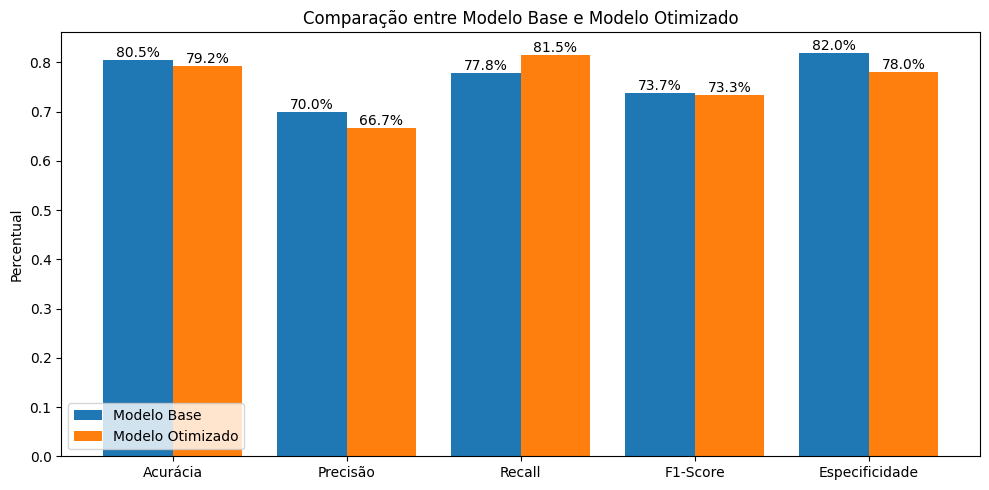

In [83]:
plt.figure(figsize=(10, 5))

indice = range(len(comparacao_modelos))

barras_base = plt.bar(
    [i - 0.2 for i in indice],
    comparacao_modelos["Modelo Base"],
    width=0.4,
    label="Modelo Base"
)

barras_otimizado = plt.bar(
    [i + 0.2 for i in indice],
    comparacao_modelos["Modelo Otimizado"],
    width=0.4,
    label="Modelo Otimizado"
)

# Valores do modelo base
for barra in barras_base:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.1%}',
        ha='center',
        va='bottom'
    )

# Valores do modelo otimizado
for barra in barras_otimizado:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.1%}',
        ha='center',
        va='bottom'
    )

plt.xticks(
    indice,
    comparacao_modelos["Métrica"]
)

plt.ylabel("Percentual")

plt.title(
    "Comparação entre Modelo Base e Modelo Otimizado"
)

plt.legend()

plt.tight_layout()

plt.show()

O modelo otimizado apresentou melhora na principal métrica de avaliação para este problema: o **Recall**, que aumentou de **77,8%** para **81,5%**. Esse resultado indica uma maior capacidade do modelo em identificar corretamente pacientes com diabetes, reduzindo a ocorrência de falsos negativos.

Em contrapartida, houve uma pequena redução na **Acurácia** (80,5% para 79,2%), na **Precisão** (70,0% para 66,7%), no **F1-Score** (73,7% para 73,3%) e na **Especificidade** (82,0% para 78,0%).

Entretanto, antes de concluir se essa redução representa um impacto significativo, é importante analisar a **matriz de confusão**. Como o objetivo deste trabalho é apoiar o diagnóstico de diabetes, a métrica mais importante é o **Recall**, pois reduzir falsos negativos é mais crítico do que aumentar falsos positivos. Dessa forma, identificar corretamente pacientes com a doença é prioritário, mesmo que isso resulte em uma pequena perda de especificidade.

## Comparação entre as Matrizes de Confusão

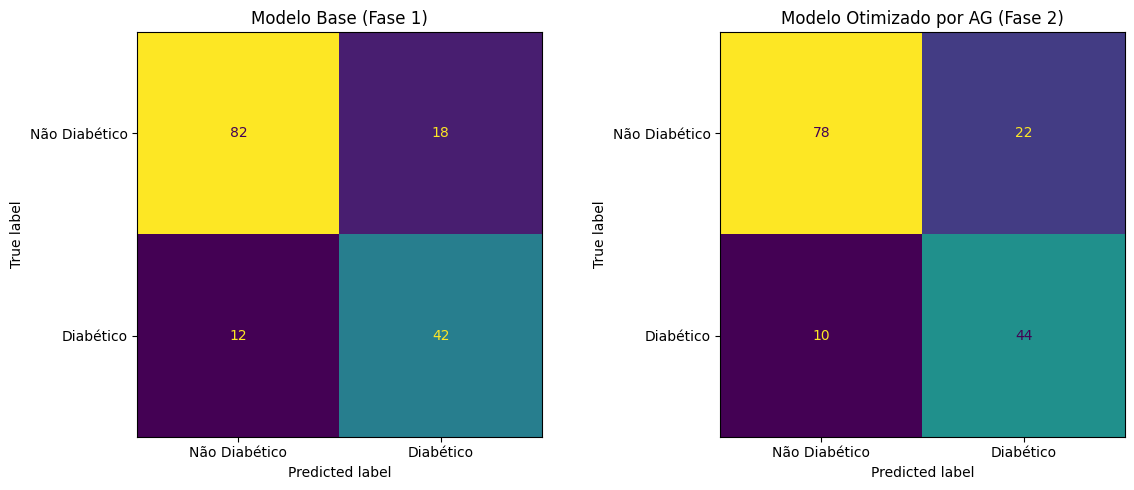

In [84]:
matriz_confusao_original = confusion_matrix(
    y_true=y_test,
    y_pred=y_predito_random_forest,
    labels=[0, 1]
)

matriz_confusao_otimizada = confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_random_forest_otimizado,
    labels=[0, 1]
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

# Modelo original
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_original,
    display_labels=['Não Diabético', 'Diabético']
).plot(
    ax=axes[0],
    values_format='d',
    colorbar=False
)

axes[0].set_title(
    'Modelo Base (Fase 1)'
)

# Modelo otimizado
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_otimizada,
    display_labels=['Não Diabético', 'Diabético']
).plot(
    ax=axes[1],
    values_format='d',
    colorbar=False
)

axes[1].set_title(
    'Modelo Otimizado por AG (Fase 2)'
)

plt.tight_layout()

plt.show()

Observando a comparação das matrizes de confusão, o modelo otimizado reduziu a quantidade de **falsos negativos** de **12 para 10 casos**. Em aplicações médicas, essa redução é especialmente importante, pois diminui a probabilidade de pacientes com diabetes serem classificados incorretamente como não diabéticos.

Em contrapartida, houve um pequeno aumento na quantidade de **falsos positivos** (de 18 para 22 casos), o que impactou a especificidade do modelo. No entanto, para este cenário, esse comportamento é aceitável, pois o principal objetivo é reduzir a ocorrência de falsos negativos, minimizando o risco de deixar pacientes diabéticos sem um encaminhamento para avaliação médica.

Dessa forma, os resultados demonstram que a otimização por **Algoritmo Genético (AG)** contribuiu para aumentar a sensibilidade do modelo, tornando-o mais adequado como ferramenta de apoio ao diagnóstico de diabetes, onde identificar corretamente os pacientes com a doença é mais importante do que evitar um pequeno aumento de falsos positivos.

# Integração com LLMs (Large Language Models)

Nesta etapa, o modelo otimizado é integrado a uma **Large Language Model (LLM)** com o objetivo de transformar os resultados numéricos das predições em explicações clínicas escritas em linguagem natural.

## Prompt Engineering para Geração do Relatório Clínico

In [85]:
def montar_prompt_relatorio_clinico(
    glicose,
    imc,
    idade,
    classificacao,
    probabilidade
):

    prompt = f"""
Você é um assistente especializado em análise de diagnóstico de diabetes chamado dIAbetes.

Analise os dados abaixo:

Glicose: {glicose}
IMC: {imc}
Idade: {idade}

Classificação do modelo: {classificacao}

Probabilidade estimada: {probabilidade:.2f}%

Gere uma breve resposta em linguagem natural contendo:

- resumo do resultado;
- principais fatores que influenciaram a classificação;
- interpretação da probabilidade estimada;
- recomendação geral;
- aviso de que o resultado não substitui avaliação médica.

Regras:
- Escreva em um único texto fluido.
- Não utilize listas ou tópicos.
- Não utilize markdown.
- Não invente informações que não estejam relacionadas aos dados fornecidos.
- Utilize linguagem clara, objetiva e profissional.
- Limite a resposta a no máximo 5 linhas.
- Responda em português brasileiro.
"""

    return prompt

## Testes Unitários - teste_deve_montar_prompt_relatorio_clinico()

In [86]:
def teste_deve_montar_prompt_relatorio_clinico():

    try:
        prompt = montar_prompt_relatorio_clinico(
            glicose=140,
            imc=32.5,
            idade=45,
            classificacao="Diabético",
            probabilidade=81.48
        )

        assert "Glicose: 140" in prompt
        assert "Classificação do modelo: Diabético" in prompt
        assert "Probabilidade estimada: 81.48%" in prompt

        print("✅ Teste executado com sucesso!")

    except AssertionError:
        print("❌ Falha no teste!")

teste_deve_montar_prompt_relatorio_clinico()

✅ Teste executado com sucesso!


## Geração do Relatório Clínico

In [87]:
def gerar_relatorio_clinico(
    glicose,
    imc,
    idade,
    classificacao,
    probabilidade
):

    try:

        prompt = montar_prompt_relatorio_clinico(
            glicose,
            imc,
            idade,
            classificacao,
            probabilidade
        )

        resposta = chat(
            model='gemma3:4b',
            messages=[
                {
                    'role': 'user',
                    'content': prompt
                }
            ],
            options={
                'temperature': 0.4
            }
        )

        return resposta['message']['content']

    except Exception as erro:

        return (
            f"Erro ao gerar relatório clínico: "
            f"{str(erro)}"
        )

## Teste de Integração - teste_gerar_relatorio_clinico()

In [91]:
def teste_gerar_relatorio_clinico():

    try:

        relatorio = gerar_relatorio_clinico(
            glicose=140,
            imc=32.5,
            idade=45,
            classificacao="DIABÉTICO",
            probabilidade=81.48
        )

        assert relatorio is not None
        assert isinstance(relatorio, str)
        assert len(relatorio.strip()) > 0
        assert "Erro ao gerar relatório clínico" not in relatorio

        print("✅ Teste executado com sucesso!")
        print("O relatório clínico foi gerado com sucesso.\n")
        print(relatorio)

    except AssertionError:

        print("❌ Falha no teste!")
        print("O relatório clínico não foi gerado corretamente.")

teste_gerar_relatorio_clinico()

✅ Teste executado com sucesso!
O relatório clínico foi gerado com sucesso.

Com base nos dados fornecidos – glicose de 140 mg/dL, IMC de 32.5 e idade de 45 anos – o modelo diagnosticou diabetes com uma probabilidade estimada de 81.48%. A glicemia elevada e o IMC indicam sobrepeso/obesidade, que são fatores de risco significativos para o desenvolvimento do diabetes. Essa alta probabilidade sugere uma forte suspeita de que o paciente possa ter diabetes, necessitando de investigação mais aprofundada. Recomendamos fortemente que o paciente procure um médico para avaliação clínica completa e confirmação do diagnóstico, lembrando que este resultado é apenas uma estimativa e não substitui a consulta médica.


## Predição de Novos Pacientes com o Modelo Otimizado

In [94]:
def prever_paciente_modelo_otimizado(dados_paciente):

    novo_paciente = pd.DataFrame([dados_paciente])

    predicao = pipeline_random_forest_otimizado.predict(
        novo_paciente
    )

    probabilidade = (
        pipeline_random_forest_otimizado
        .predict_proba(novo_paciente)
    )

    classificacao = (
        "DIABÉTICO"
        if predicao[0] == 1
        else "NÃO DIABÉTICO"
    )

    probabilidade_diabetes = (
        probabilidade[0][1] * 100
    )

    print(
        f"Paciente classificado como: "
        f"{classificacao}"
    )

    print(
        f"Probabilidade de diabetes: "
        f"{probabilidade_diabetes:.2f}%"
    )

    print("-" * 50)

    return {
        "classificacao": classificacao,
        "probabilidade": probabilidade_diabetes
    }

In [96]:
def teste_prever_paciente_modelo_otimizado():

    try:

        paciente = {
            'Glucose': 160,
            'BMI': 33,
            'Age': 40,
            'Pregnancies': 2,
            'DiabetesPedigreeFunction': 0.5
        }

        resultado = prever_paciente_modelo_otimizado(
            paciente
        )

        assert isinstance(resultado, dict)
        assert "classificacao" in resultado
        assert "probabilidade" in resultado

        assert resultado["classificacao"] in [
            "DIABÉTICO",
            "NÃO DIABÉTICO"
        ]

        assert 0 <= resultado["probabilidade"] <= 100

        print("✅ Teste executado com sucesso!")
        print("A predição do paciente foi realizada com sucesso.")

    except AssertionError:

        print("❌ Falha no teste!")
        print("A predição retornou um resultado inválido.")

teste_prever_paciente_modelo_otimizado()

Paciente classificado como: DIABÉTICO
Probabilidade de diabetes: 62.70%
--------------------------------------------------
✅ Teste executado com sucesso!
A predição do paciente foi realizada com sucesso.


## Array de Pacientes
> Adicione quantos pacientes desejar para realizar novos testes.


In [97]:

pacientes = [
    {
        'Glucose': 140,
        'BMI': 32,
        'Age': 45,
        'Pregnancies': 2,
        'DiabetesPedigreeFunction': 0.5
    },
    {
        'Glucose': 90,
        'BMI': 22,
        'Age': 25,
        'Pregnancies': 0,
        'DiabetesPedigreeFunction': 0.2
    },
    {
        'Glucose': 180,
        'BMI': 35,
        'Age': 50,
        'Pregnancies': 4,
        'DiabetesPedigreeFunction': 0.8
    },
    {
        'Glucose': 220,
        'BMI': 25,
        'Age': 32,
        'Pregnancies': 0,
        'DiabetesPedigreeFunction': 1
    },
    {
        'Glucose': 70,
        'BMI': 25,
        'Age': 18,
        'Pregnancies': 0,
        'DiabetesPedigreeFunction': 0.5
    }
]

## Predição e Geração dos Relatórios Clínicos

In [98]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print("\n===== PREDIÇÕES PARA NOVOS PACIENTES =====\n")

relatorios_gerados = []

for i, paciente in enumerate(pacientes, start=1):

    print(
        f"Paciente {i} | "
        f"Glicose: {paciente['Glucose']}, "
        f"IMC: {paciente['BMI']}, "
        f"Idade: {paciente['Age']}"
    )

    resultado = prever_paciente_modelo_otimizado(
        paciente
    )

    relatorio = gerar_relatorio_clinico(
            glicose=paciente["Glucose"],
            imc=paciente["BMI"],
            idade=paciente["Age"],
            classificacao=resultado["classificacao"],
            probabilidade=resultado["probabilidade"]
    )

    relatorios_gerados.append({
            "glicose": paciente["Glucose"],
            "imc": paciente["BMI"],
            "idade": paciente["Age"],
            "gestacoes": paciente["Pregnancies"],
            "historico_familiar": paciente["DiabetesPedigreeFunction"],
            "classificacao": resultado["classificacao"],
            "probabilidade": round(
                resultado["probabilidade"],
                2
            ),
            "relatorio_llm": relatorio
    })

    print("\nRELATÓRIO CLÍNICO GERADO PELA LLM\n")

    print(relatorio)

    print(
            "\n" + "=" * 80 + "\n"
        )


===== PREDIÇÕES PARA NOVOS PACIENTES =====

Paciente 1 | Glicose: 140, IMC: 32, Idade: 45
Paciente classificado como: DIABÉTICO
Probabilidade de diabetes: 62.39%
--------------------------------------------------

RELATÓRIO CLÍNICO GERADO PELA LLM

Com base nos dados fornecidos – glicose de 140 mg/dL, IMC de 32 e idade de 45 anos – o modelo de diagnóstico de diabetes classificou o indivíduo como “DIABÉTICO”, com uma probabilidade estimada de 62.39%. A glicemia elevada e o IMC acima do recomendado são os principais fatores que influenciaram essa classificação, indicando um risco aumentado para o desenvolvimento da doença. A probabilidade de 62.39% sugere que, com base nesses dados, a predição de diabetes é considerada moderada. É fundamental procurar avaliação médica imediata para confirmar o diagnóstico e iniciar o tratamento adequado, lembrando que este resultado não substitui a consulta e o exame clínico de um profissional de saúde.


Paciente 2 | Glicose: 90, IMC: 22, Idade: 25
Pac

# Criação da Base de Relatórios Clínicos

In [ ]:
df_relatorios_llm = pd.DataFrame(
    relatorios_gerados
)

print("\n===== BASE DE RELATÓRIOS GERADA =====\n")

display(df_relatorios_llm)

# CSV
df_relatorios_llm.to_csv(
    "../dataset/raw/base_relatorios_llm.csv",
    index=False,
    encoding="utf-8-sig"
)

# Excel
df_relatorios_llm.to_excel("../dataset/raw/base_relatorios_llm.xlsx", index=False)

print(
    f"\n{len(df_relatorios_llm)} relatórios "
    "salvos com sucesso."
)

print(
    "Arquivos gerados:"
)

print(
    "- ../dataset/raw/base_relatorios_llm.csv"
)

print(
    "- ../dataset/raw/base_relatorios_llm.xlsx"
)


===== BASE DE RELATÓRIOS GERADA =====



,glicose,imc,idade,gestacoes,historico_familiar,classificacao,probabilidade,relatorio_llm
0,140,32,45,2,0.5,DIABÉTICO,62.39,"Com base nos dados fornecidos – glicose de 140 mg/dL, IMC de 32 e idade de 45 anos – o modelo de diagnóstico de diabetes classificou o indivíduo como “DIABÉTICO”, com uma probabilidade estimada de 62.39%. A glicemia elevada e o IMC acima do recomendado são os principais fatores que influenciaram essa classificação, indicando um risco aumentado para o desenvolvimento da doença. A probabilidade de 62.39% sugere que, com base nesses dados, a predição de diabetes é considerada moderada. É fundamental procurar avaliação médica imediata para confirmar o diagnóstico e iniciar o tratamento adequado, lembrando que este resultado não substitui a consulta e o exame clínico de um profissional de saúde."
1,90,22,25,0,0.2,NÃO DIABÉTICO,24.66,"Com base nos dados fornecidos, o modelo classificou o paciente como NÃO DIABÉTICO com uma probabilidade estimada de 24.66%. A glicose de 90 mg/dL e o IMC de 22 indicam um controle glicêmico e peso saudáveis, sendo fatores que contribuíram para essa classificação. Apesar da baixa probabilidade de 24.66%, é importante ressaltar que essa análise é apenas uma estimativa e não substitui a avaliação completa de um profissional de saúde. Recomendamos fortemente a realização de exames adicionais e acompanhamento médico para garantir a saúde do paciente, pois este resultado não dispensa a consulta e avaliação por um médico."
2,180,35,50,4,0.8,DIABÉTICO,63.03,"Com base nos dados fornecidos, o modelo classificou o paciente como diabético com uma probabilidade estimada de 63.03%. A glicemia elevada de 180 mg/dL, juntamente com o IMC de 35, que indica obesidade, foram os principais fatores que influenciaram essa classificação. Essa probabilidade de 63.03% sugere que, com base nesses dados, há uma chance considerável de o paciente ter diabetes. Recomendamos fortemente que o paciente procure avaliação médica completa para confirmar o diagnóstico e iniciar o tratamento adequado. É importante ressaltar que este resultado é apenas uma estimativa e não substitui a avaliação e o julgamento de um profissional de saúde."
3,220,25,32,0,1.0,DIABÉTICO,51.50,"Com base nos dados fornecidos – glicose de 220 mg/dL, IMC de 25 e idade de 32 anos – o modelo classificou o paciente como “DIABÉTICO” com uma probabilidade estimada de 51.50%. A glicemia elevada e o IMC indicam um risco aumentado para o desenvolvimento da doença. A probabilidade de 51.50% sugere que, embora os fatores apontem para a diabetes, ainda existe uma chance de 48.50% de que a condição não seja diagnosticada. Recomendamos fortemente que o paciente procure avaliação médica imediata para confirmar o diagnóstico e iniciar o tratamento adequado. É importante ressaltar que este resultado é apenas uma estimativa e não substitui a avaliação completa de um profissional de saúde."
4,70,25,18,0,0.5,NÃO DIABÉTICO,21.18,"Com base nos dados fornecidos – glicose de 70 mg/dL, IMC de 25 e idade de 18 anos – o modelo classificou o indivíduo como NÃO DIABÉTICO, com uma probabilidade estimada de 21,18% de não ter a doença. A glicose baixa e a idade jovem são fatores que contribuíram positivamente para essa classificação. No entanto, a probabilidade de 21,18% indica uma pequena chance de diabetes, que ainda merece atenção. Recomendamos um acompanhamento médico para avaliação completa e, se necessário, exames adicionais, lembrando que este resultado não substitui uma consulta médica e diagnóstico profissional."



5 relatórios salvos com sucesso.
Arquivos gerados:
- ../dataset/raw/base_relatorios_llm.csv
- ../dataset/raw/base_relatorios_llm.xlsx


# Conclusão

Ao analisar os resultados obtidos, podemos concluir que a utilização do **Algoritmo Genético** conseguiu melhorar o desempenho do modelo desenvolvido na Fase 1, aumentando o **Recall** de **77,8%** para **81,5%** e reduzindo a quantidade de **falsos negativos** de **12 para 10 casos**. Como o objetivo é apoiar o diagnóstico de diabetes, essa melhoria é importante por aumentar a identificação correta de pacientes com a doença.

Além da otimização do modelo, foi realizada a integração com uma **LLM** executada localmente utilizando o **Ollama**, permitindo transformar as predições em explicações clínicas em linguagem natural. Isso tornou os resultados mais fáceis de interpretar e aproximou a solução de um cenário real de apoio à decisão médica.

Por fim, os relatórios gerados pela LLM foram armazenados para utilização nas próximas fases do projeto. Dessa forma, o sistema final integra **Machine Learning**, **Algoritmos Genéticos** e **Inteligência Artificial Generativa**. Assim como na Fase 1, a solução deve ser utilizada apenas como ferramenta de apoio, não substituindo a avaliação e o diagnóstico realizados por um profissional de saúde.